# RDF. Сериализация RDF-графа в форматы N-Triples и Turtle.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Курс лекций [Semantic Technologies for Developers](https://yadi.sk/d/SepS4JBLhDYy4Q), лекция №01
* https://www.w3.org/TR/rdf12-n-triples/
* https://www.w3.org/TR/turtle/
* https://www.w3.org/2015/03/ShExValidata/
* https://networkx.org/documentation/stable/reference/classes/digraph.html
* https://networkx.org/documentation/stable/reference/drawing.html
* https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_labels.html

## Вопросы для совместного обсуждения

1\. Обсудите модель RDF, способы представления (сериализации) RDF-графов и проблему материализации (reification) данных.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Дан фрагмент текста. Разбейте данный текст на тройки субъект-предикат-объект и сохраните в виде списка кортежей. Для каждого субъекта и нелитерального объекта введите уникальный строковый идентификатор вида `ID-{N}`. Типы отношений оформите в виде перечисления `Relation`.

Выведите на экран количество созданных троек и количество введенных идентификаторов.

Для разбиения не используйте никаких дополнительных инструментов, работайте полностью в ручном режиме. 

- [ ] Проверено на семинаре

В небольшом городке Зеленогорск живет талантливый художник Анна Петрова. Ей 35 лет, и она специализируется на пейзажной живописи. Анна создала серию картин под названием "Времена года", состоящую из четырех полотен.

Первая картина из серии, "Весеннее пробуждение", была написана в 2021 году. Она изображает цветущий яблоневый сад на фоне голубого неба. Размер холста - 80 на 60 сантиметров. Эта работа была продана на местном аукционе за 150000 рубле За рубежом данная картина известна под названием "Spring Awakening".



Анна использует в своем творчестве различные техники. Для "Весеннего пробуждения" она применила метод импасто, создавая объемные мазки масляными красками. Любимыми цветами художницы являются зеленый и синий, что отчетливо видно в ее работах.

Мастерская Анны находится на улице Лесная, дом 7. Здесь она не только работает над своими картинами, но и проводит мастер-классы для начинающих художников. Ее уроки пользуются большой популярностью, и записаться на них можно по телефону +7 (123) 456-78-90.

In [ ]:
from enum import Enum, auto

class Relation(Enum):
    # Личные данные
    NAME = auto()
    SURNAME = auto() 
    AGE = auto()
    LIVES_IN = auto()
    
    # Профессиональная деятельность
    PROFESSION = auto()
    SPECIALIZES_IN = auto()
    CREATED = auto()
    PAINTED = auto()
    USES_TECHNIQUE = auto()
    FAVORITE_COLOR = auto()
    
    # Свойства объектов
    TITLE = auto()
    PART_OF = auto()
    SIZE = auto()
    YEAR_CREATED = auto()
    DEPICTS = auto()
    SOLD_FOR = auto()
    KNOWN_AS = auto()
    CONSISTS_OF = auto()
    
    # Местоположение и контакты
    LOCATED_AT = auto()
    ADDRESS = auto()
    CONDUCTS = auto()
    PHONE = auto()
    
    # Описательные отношения
    COLOR = auto()
    BACKGROUND = auto()
    

In [ ]:
# Список для хранения троек
triplets: list[tuple[str, Relation, str]] = []

# Счетчик для генерации уникальных ID
id_counter = 1
entity_ids = {}

def get_or_create_id(entity_name):
    """Получить существующий ID или создать новый для сущности"""
    global id_counter
    if entity_name not in entity_ids:
        entity_ids[entity_name] = f"ID-{id_counter}"
        id_counter += 1
    return entity_ids[entity_name]

# Пошаговое извлечение троек из текста

# 1. "В небольшом городке Зеленогорск живет талантливый художник Анна Петрова"
anna_id = get_or_create_id("Анна Петрова")
zelenogorks_id = get_or_create_id("Зеленогорск")

triplets.append((anna_id, Relation.NAME, "Анна"))
triplets.append((anna_id, Relation.SURNAME, "Петрова"))
triplets.append((anna_id, Relation.LIVES_IN, zelenogorks_id))
triplets.append((anna_id, Relation.PROFESSION, "художник"))

# 2. "Ей 35 лет"
triplets.append((anna_id, Relation.AGE, "35"))

# 3. "она специализируется на пейзажной живописи"
triplets.append((anna_id, Relation.SPECIALIZES_IN, "пейзажная живопись"))

# 4. "Анна создала серию картин под названием 'Времена года'"
series_id = get_or_create_id("Времена года")
triplets.append((anna_id, Relation.CREATED, series_id))
triplets.append((series_id, Relation.TITLE, "Времена года"))

# 5. "состоящую из четырех полотен"
triplets.append((series_id, Relation.CONSISTS_OF, "четыре полотна"))

# 6. "Первая картина из серии, 'Весеннее пробуждение'"
spring_painting_id = get_or_create_id("Весеннее пробуждение")
triplets.append((spring_painting_id, Relation.TITLE, "Весеннее пробуждение"))
triplets.append((spring_painting_id, Relation.PART_OF, series_id))

# 7. "была написана в 2021 году"
triplets.append((spring_painting_id, Relation.YEAR_CREATED, "2021"))
triplets.append((anna_id, Relation.PAINTED, spring_painting_id))

# 8. "Она изображает цветущий яблоневый сад на фоне голубого неба"
apple_garden_id = get_or_create_id("цветущий яблоневый сад")
blue_sky_id = get_or_create_id("голубое небо")

triplets.append((spring_painting_id, Relation.DEPICTS, apple_garden_id))
triplets.append((apple_garden_id, Relation.BACKGROUND, blue_sky_id))
triplets.append((blue_sky_id, Relation.COLOR, "голубой"))

# 9. "Размер холста - 80 на 60 сантиметров"
triplets.append((spring_painting_id, Relation.SIZE, "80x60 см"))

# 10. "была продана на местном аукционе за 150000 рублей"
triplets.append((spring_painting_id, Relation.SOLD_FOR, "150000 рублей"))

# 11. "За рубежом данная картина известна под названием 'Spring Awakening'"
triplets.append((spring_painting_id, Relation.KNOWN_AS, "Spring Awakening"))

# 12. "Для 'Весеннего пробуждения' она применила метод импасто"
impasto_id = get_or_create_id("импасто")
triplets.append((anna_id, Relation.USES_TECHNIQUE, impasto_id))
triplets.append((impasto_id, Relation.TITLE, "импасто"))

# 13. "Любимыми цветами художницы являются зеленый и синий"
triplets.append((anna_id, Relation.FAVORITE_COLOR, "зеленый"))
triplets.append((anna_id, Relation.FAVORITE_COLOR, "синий"))

# 14. "Мастерская Анны находится на улице Лесная, дом 7"
workshop_id = get_or_create_id("мастерская Анны")
address_id = get_or_create_id("улица Лесная, дом 7")

triplets.append((anna_id, Relation.LOCATED_AT, workshop_id))
triplets.append((workshop_id, Relation.ADDRESS, address_id))

# 15. "проводит мастер-классы"
masterclasses_id = get_or_create_id("мастер-классы")
triplets.append((anna_id, Relation.CONDUCTS, masterclasses_id))

# 16. "записаться на них можно по телефону +7 (123) 456-78-90"
triplets.append((anna_id, Relation.PHONE, "+7 (123) 456-78-90"))

# Выводим результаты
print("=== РЕЗУЛЬТАТЫ АНАЛИЗА ===")
print(f"Количество созданных троек: {len(triplets)}")
print(f"Количество введенных идентификаторов: {len(entity_ids)}")

print("\n=== СОЗДАННЫЕ ИДЕНТИФИКАТОРЫ ===")
for entity, entity_id in entity_ids.items():
    print(f"{entity_id}: {entity}")

print("\n=== ТРОЙКИ СУБЪЕКТ-ПРЕДИКАТ-ОБЪЕКТ ===")
for i, (subject, predicate, obj) in enumerate(triplets, 1):
    # Показываем читаемые названия для ID
    subject_name = subject
    obj_name = obj
    
    # Ищем читаемые имена для ID
    for entity, entity_id in entity_ids.items():
        if subject == entity_id:
            subject_name = f"{subject} ({entity})"
        if obj == entity_id:
            obj_name = f"{obj} ({entity})"
    
    print(f"{i:2d}. {subject_name} --{predicate.name}--> {obj_name}")

print(f"\n=== СВОДКА ===")
print(f"Всего троек: {len(triplets)}")
print(f"Всего уникальных идентификаторов: {len(entity_ids)}")
print(f"Всего типов отношений: {len(set(trip[1] for trip in triplets))}")

# Проверяем структуру данных
print("\n=== ПРОВЕРКА СТРУКТУРЫ ===")
print("Первые 5 троек в формате (ID, Relation, значение):")
for i in range(min(5, len(triplets))):
    print(f"  {triplets[i]}")

<p class="task" id="2"></p>

2\. Используя триплеты, созданные в предыдущем задании, создайте ориентированный граф `nx.DiGraph`. На каждом ребре создайте атрибут `type`, в котором хранится значение типа отношений (`Relation`).

Визуализируйте полученный граф. Добавьте на узлы и ребра подписи. В качестве ребер подписи используйте название перечисляемого значения. Сделайте нелитеральные субъекты и объекты зелеными, а литеральные объекты - серыми.

- [ ] Проверено на семинаре

In [ ]:
def create_triplets():
    triplets = []
    id_counter = 1
    entity_ids = {}
    
    def get_or_create_id(entity_name):
        nonlocal id_counter
        if entity_name not in entity_ids:
            entity_ids[entity_name] = f"ID-{id_counter}"
            id_counter += 1
        return entity_ids[entity_name]
    
    # Создаем те же тройки, что и в предыдущем задании
    anna_id = get_or_create_id("Анна Петрова")
    zelenogorks_id = get_or_create_id("Зеленогорск")
    
    triplets.append((anna_id, Relation.NAME, "Анна"))
    triplets.append((anna_id, Relation.SURNAME, "Петрова"))
    triplets.append((anna_id, Relation.LIVES_IN, zelenogorks_id))
    triplets.append((anna_id, Relation.PROFESSION, "художник"))
    triplets.append((anna_id, Relation.AGE, "35"))
    triplets.append((anna_id, Relation.SPECIALIZES_IN, "пейзажная живопись"))
    
    series_id = get_or_create_id("Времена года")
    triplets.append((anna_id, Relation.CREATED, series_id))
    triplets.append((series_id, Relation.TITLE, "Времена года"))
    triplets.append((series_id, Relation.CONSISTS_OF, "четыре полотна"))
    
    spring_painting_id = get_or_create_id("Весеннее пробуждение")
    triplets.append((spring_painting_id, Relation.TITLE, "Весеннее пробуждение"))
    triplets.append((spring_painting_id, Relation.PART_OF, series_id))
    triplets.append((spring_painting_id, Relation.YEAR_CREATED, "2021"))
    triplets.append((anna_id, Relation.PAINTED, spring_painting_id))
    
    apple_garden_id = get_or_create_id("цветущий яблоневый сад")
    blue_sky_id = get_or_create_id("голубое небо")
    
    triplets.append((spring_painting_id, Relation.DEPICTS, apple_garden_id))
    triplets.append((apple_garden_id, Relation.BACKGROUND, blue_sky_id))
    triplets.append((blue_sky_id, Relation.COLOR, "голубой"))
    triplets.append((spring_painting_id, Relation.SIZE, "80x60 см"))
    triplets.append((spring_painting_id, Relation.SOLD_FOR, "150000 рублей"))
    triplets.append((spring_painting_id, Relation.KNOWN_AS, "Spring Awakening"))
    
    impasto_id = get_or_create_id("импасто")
    triplets.append((anna_id, Relation.USES_TECHNIQUE, impasto_id))
    triplets.append((impasto_id, Relation.TITLE, "импасто"))
    
    triplets.append((anna_id, Relation.FAVORITE_COLOR, "зеленый"))
    triplets.append((anna_id, Relation.FAVORITE_COLOR, "синий"))
    
    workshop_id = get_or_create_id("мастерская Анны")
    address_id = get_or_create_id("улица Лесная, дом 7")
    
    triplets.append((anna_id, Relation.LOCATED_AT, workshop_id))
    triplets.append((workshop_id, Relation.ADDRESS, address_id))
    
    masterclasses_id = get_or_create_id("мастер-классы")
    triplets.append((anna_id, Relation.CONDUCTS, masterclasses_id))
    triplets.append((anna_id, Relation.PHONE, "+7 (123) 456-78-90"))
    
    return triplets, entity_ids

# Создаем тройки
triplets, entity_ids = create_triplets()

print(f"Загружено {len(triplets)} троек")
print(f"Создано {len(entity_ids)} идентификаторов")

# Создаем ориентированный граф
G = nx.DiGraph()

# Функция для определения, является ли узел литеральным
def is_literal(node):
    """Определяет, является ли узел литеральным значением"""
    # Литералы - это строки, которые НЕ являются ID
    return not node.startswith("ID-")

# Добавляем узлы и рёбра
for subject, relation, obj in triplets:
    # Добавляем узлы, если их еще нет
    if subject not in G:
        G.add_node(subject)
    if obj not in G:
        G.add_node(obj)
    
    # Добавляем ребро с атрибутом типа отношения
    G.add_edge(subject, obj, type=relation)

print(f"Граф создан: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер")

# Создаем обратный словарь для получения имен сущностей по ID
id_to_name = {v: k for k, v in entity_ids.items()}

# Функция для получения читаемого имени узла
def get_node_label(node):
    """Возвращает читаемое название для узла"""
    if node.startswith("ID-"):
        return f"{node}\n({id_to_name.get(node, 'Unknown')})"
    else:
        # Для литералов ограничиваем длину
        if len(node) > 15:
            return node[:12] + "..."
        return node

# Настройка визуализации
plt.figure(figsize=(20, 16))
plt.title("RDF Граф: Информация об Анне Петровой", fontsize=16, fontweight='bold')

# Используем spring layout для лучшего расположения узлов
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Определяем цвета узлов
node_colors = []
for node in G.nodes():
    if is_literal(node):
        node_colors.append('lightgray')  # Литералы - серые
    else:
        node_colors.append('lightgreen')  # Нелитеральные - зеленые

# Рисуем узлы
nx.draw_networkx_nodes(G, pos, 
                      node_color=node_colors,
                      node_size=3000,
                      alpha=0.8,
                      edgecolors='black',
                      linewidths=1)

# Рисуем рёбра
nx.draw_networkx_edges(G, pos,
                      edge_color='black',
                      arrows=True,
                      arrowsize=20,
                      arrowstyle='->',
                      width=1.5,
                      alpha=0.7)

# Добавляем подписи к узлам
node_labels = {node: get_node_label(node) for node in G.nodes()}
nx.draw_networkx_labels(G, pos, node_labels, font_size=8, font_weight='bold')

# Добавляем подписи к рёбрам (названия отношений)
edge_labels = {}
for u, v, data in G.edges(data=True):
    relation = data['type']
    edge_labels[(u, v)] = relation.name

nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7, 
                            bbox=dict(boxstyle='round,pad=0.2', 
                                     facecolor='white', 
                                     alpha=0.8,
                                     edgecolor='none'))

# Добавляем легенду
literal_patch = mpatches.Patch(color='lightgray', label='Литеральные значения')
non_literal_patch = mpatches.Patch(color='lightgreen', label='Сущности (ID)')
plt.legend(handles=[non_literal_patch, literal_patch], loc='upper right')

plt.axis('off')  # Убираем оси
plt.tight_layout()
plt.show()

# Выводим статистику графа
print("\n=== СТАТИСТИКА ГРАФА ===")
print(f"Количество узлов: {G.number_of_nodes()}")
print(f"Количество рёбер: {G.number_of_edges()}")

print(f"\nЛитеральные узлы: {sum(1 for node in G.nodes() if is_literal(node))}")
print(f"Нелитеральные узлы (ID): {sum(1 for node in G.nodes() if not is_literal(node))}")

# Анализируем степени узлов
print(f"\nУзлы с наибольшим количеством связей:")
degrees = dict(G.degree())
sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)
for node, degree in sorted_degrees[:5]:
    label = get_node_label(node).replace('\n', ' ')
    print(f"  {label}: {degree} связей")

# Типы отношений
relation_types = [data['type'] for u, v, data in G.edges(data=True)]
unique_relations = set(relation_types)
print(f"\nИспользованные типы отношений: {len(unique_relations)}")
for relation in sorted(unique_relations, key=lambda x: x.name):
    count = relation_types.count(relation)
    print(f"  {relation.name}: {count} раз")

# Проверяем структуру
print(f"\n=== ПРОВЕРКА СТРУКТУРЫ ===")
print("Примеры рёбер с атрибутами:")
for i, (u, v, data) in enumerate(G.edges(data=True)):
    if i < 5:  # Показываем первые 5
        u_label = get_node_label(u).replace('\n', ' ')
        v_label = get_node_label(v).replace('\n', ' ')
        print(f"  {u_label} --{data['type'].name}--> {v_label}")

print(f"\nГраф успешно создан и визуализирован!")

<p class="task" id="3"></p>

3\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `N-Triples`. Для формирования URI нелитеральных сущностей используйте следующие правила:

* URI для субъекта или объекта формируйте по следующему шаблону: `http://www.fa.ru/entity/{id}`, где `domain` - это домен, к которому относится сущность (человек, город и т.д.), а `id` - числовое значение идентификатора этой сущности из задания 1. Пример: `http://www.fa.ru/entity/1`.
* URI для предиката формируйте по следующему шаблону: `http://www.fa.ru/predicate/{type}`, где `type` - это название отношения в lowerCamelCase нотации. Пример: `http://www.fa.ru/predicate/livesIn`.

Литералы указывайте в двойных кавычках без дополнительных языковых тегов или типов данных.

Результат представьте в виде строки `ntriples`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

<p class="task" id="4"></p>

4\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `N-Triples`, дополнительно указав языковые теги для строковых литералов и URI типа данных для нестроковых.

Результат представьте в виде строки `ntriples_extended`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

<p class="task" id="5"></p>

5\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `Turtle`. Для формирования URI нелитеральных сущностей используйте правила, аналогичные предыдущим заданиям. Используйте директиву `@prefix` для описания пространств имен для сущностей и предикатов. Для описания данных используйте только простые тройки вида субъект-предикат-объект, без списков предикатов и/или объектов.

Результат представьте в виде строки `turtle`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

<p class="task" id="6"></p>

6\. Сериализуйте RDF-граф, полученный в предыдущих заданиях, в формате `Turtle` с использованием списков предикатов.

Результат представьте в виде строки `turtlePredicateList`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

На странице [История языка программирования Python](https://en.wikipedia.org/wiki/History_of_Python) содержится информация о релизах основных и промежуточных версий. Требуется представить эту информацию в виде RDF-графа, где субъектом выступает сущность Python, а объектами - номера версий. Проблема заключается в том, что дополнительно к каждой тройке требуется прикрепить дополнительную информацию о датах начала и окончания поддержки конкретного релиза (т.н. квалификаторы) - т.е. решить задачу материализации (reification).

<p class="task" id="7"></p>

7\. Соберите данные о датах релиза и окончания поддержки для всех основных версий Python в виде словаря. Выведите на экран количество ключей данного словаря. Для получения информации из таблицы на странице можно воспользоваться [pandas](https://pandas.pydata.org/docs/reference/api/pandas.read_html.html).

Выполните процедуру материализации по следующей схеме (__схема 1__) и сериализуйте полученных RDF-граф в формате `Turtle`. При сериализации используйте префиксы, указанные ниже. Для узлов с префиксом `statement` вы должны сгенерировать уникальный идентификатор. Можете сделать это любым удобным способом, например, воспользоваться [uuid](https://docs.python.org/3/library/uuid.html). Результат представьте в виде строки `pythonVersionsV1`. Выведите полученную строку на экран. 

Не используйте готовых решений для сериализации. Допускается автоматизированное формирование сериализованного представления при помощи собственных реализаций (генерация URI и т.д.).

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

```turtle
@prefix hasSubject: <http://www.fa.ru/hasSubject/> .
@prefix hasPredicate: <http://www.fa.ru/hasPredicate/> . 
@prefix hasObject: <http://www.fa.ru/hasObject/> .
@prefix entity: <http://www.fa.ru/entity/> .
@prefix predicate: <http://www.fa.ru/predicate/> .
@prefix statement: <http://www.fa.ru/statement/> .

```

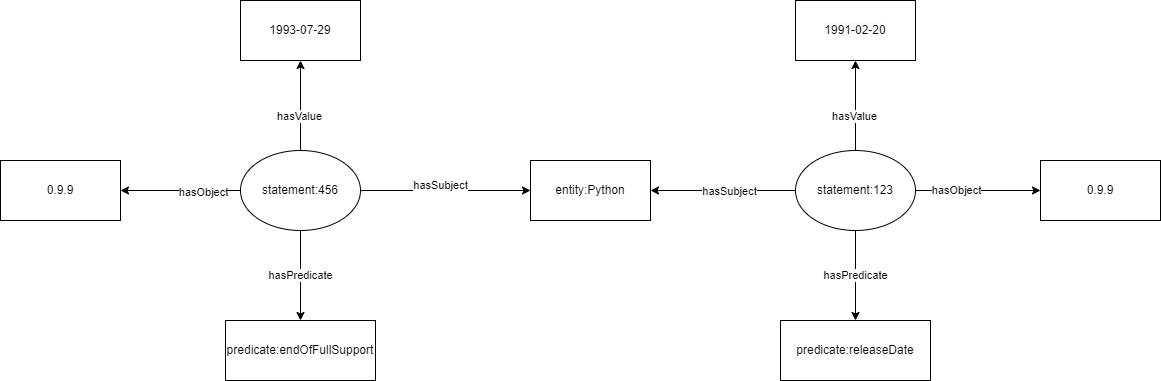

In [ ]:
from typing import TypedDict

class Qualifiers(TypedDict):
    release_date: str
    end_of_full_support: str

python_versions: dict[str, TypedDict] = {}

<p class="task" id="8"></p>

8\. Выполните процедуру материализации по следующей схеме (__схема 2__) и сериализуйте полученных RDF-граф в формате `Turtle`. Результат представьте в виде строки `pythonVersionsV2`. Выведите полученную строку на экран. 

Для проверки результата используйте [валидатор](https://www.w3.org/2015/03/ShExValidata/). Вставьте в ноутбук скриншот с подтверждением корректности полученного результата.

- [ ] Проверено на семинаре

```turtle
@prefix e: <http://www.fa.ru/entity/> .
@prefix p: <http://www.fa.ru/prop/> .
@prefix pq: <http://www.fa.ru/prop/qualifier/> .
@prefix ps: <http://www.fa.ru/prop/statement/> .
@prefix s: <http://www.wikidata.org/entity/statement/> .

`````

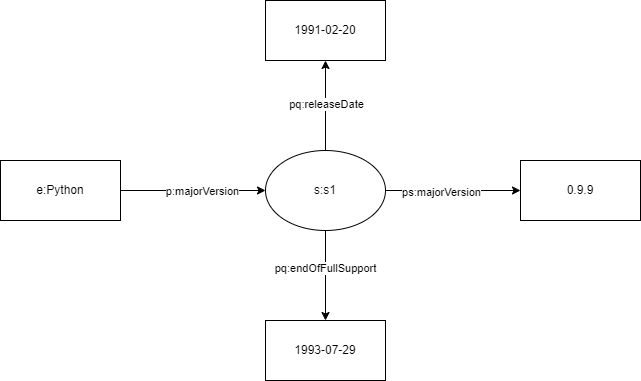